# 01 — precondition: is the spread mean-reverting, and does it survive train→OOS?

Before we ever write a trading rule, one cheap question decides whether pairs
trading on `ETHUSDT/BTCUSDT` is even worth pursuing: **does the log-spread
actually revert to a mean — and does that property hold on a *different*
period than the one we fit on?**

The trap we are guarding against (learned the hard way in the pump study):
picking a pair because it "looks co-moving" over the whole chart is a mild form
of lookahead. A pair cointegrated in H1-2024 is *not obligated* to stay
cointegrated in H2-2024. So we:

1. **Fit β (the hedge ratio) on TRAIN only** — the first half of 2024.
2. **Apply that same β forward** to the second half (OOS) — no re-fitting.
3. Ask on **both** windows: half-life of reversion, and an ADF test
   (a standard statistical test for "does this series pull back to a mean").

Plain-language glossary for the terms below:
- **β (beta / hedge ratio):** how many BTC we short per 1 ETH so the combined
  position is roughly market-neutral. Estimated by regressing log(ETH) on log(BTC).
- **half-life:** if the spread is stretched away from its mean, how many bars
  (hours here) until it closes *half* the gap on average. Short half-life =
  fast, tradeable reversion. `nan` = not reverting at all.
- **ADF (Augmented Dickey-Fuller) p-value:** tests the hypothesis "this series
  wanders forever (random walk)". A **small** p (< 0.05) lets us reject that →
  evidence the series is mean-reverting (stationary). A big p = looks like a
  random walk = nothing to trade.

In [1]:
import sys; sys.path.insert(0, ".")   # cwd = notebooks/pairs
from _lab import *
from statsmodels.tsa.stattools import adfuller

SYM_A, SYM_B = "ETHUSDT", "BTCUSDT"
TF = "1h"

# One long pull; we slice train / OOS from it. (Loading != looking — we only
# ever FIT on the train slice.)
px_all = load_pair(SYM_A, SYM_B, "2024-01-01", "2025-01-01", tf=TF)

TRAIN_END = "2024-07-01"
px_tr  = px_all.loc[:TRAIN_END].iloc[:-1]   # 2024 H1
px_oos = px_all.loc[TRAIN_END:]             # 2024 H2
print(f"train : {px_tr.index[0]}  ->  {px_tr.index[-1]}   ({len(px_tr)} bars)")
print(f"oos   : {px_oos.index[0]}  ->  {px_oos.index[-1]}   ({len(px_oos)} bars)")

train : 2024-01-01 00:00:00+00:00  ->  2024-07-01 22:00:00+00:00   (4391 bars)
oos   : 2024-07-01 00:00:00+00:00  ->  2024-12-31 23:00:00+00:00   (4416 bars)


In [2]:
# --- Fit beta on TRAIN only, then apply it forward to BOTH windows ----------
import numpy as np

la_tr, lb_tr = np.log(px_tr["a"]), np.log(px_tr["b"])
beta = float(np.polyfit(lb_tr, la_tr, 1)[0])     # OLS log(ETH) ~ log(BTC)

# spread with the SAME train-beta everywhere (this is the honest, no-refit spread)
spread_tr  = np.log(px_tr["a"])  - beta * np.log(px_tr["b"])
spread_oos = np.log(px_oos["a"]) - beta * np.log(px_oos["b"])

mu_tr, sd_tr = spread_tr.mean(), spread_tr.std()
print(f"beta (train)        = {beta:.4f}")
print(f"train spread  mean  = {mu_tr:.4f}   std = {sd_tr:.4f}")
print(f"oos   spread  mean  = {spread_oos.mean():.4f}   std = {spread_oos.std():.4f}")
print(f"  -> OOS mean drift  = {spread_oos.mean() - mu_tr:+.4f}  "
      f"({(spread_oos.mean()-mu_tr)/sd_tr:+.2f} train-std)")

beta (train)        = 0.8718
train spread  mean  = -1.5318   std = 0.0596
oos   spread  mean  = -1.7581   std = 0.1182
  -> OOS mean drift  = -0.2263  (-3.80 train-std)


In [3]:
# --- The two mean-reversion diagnostics, on EACH window ---------------------
def diagnose(s, label):
    hl = half_life(s)
    adf_stat, adf_p, *_ = adfuller(s.dropna().values, maxlag=48, autolag=None)
    print(f"{label:6s} | half-life = {hl:6.1f} bars "
          f"({hl/24:5.1f} d) | ADF p = {adf_p:.4f} "
          f"{'(reverting)' if adf_p < 0.05 else '(looks like random walk)'}")
    return hl, adf_p

print("mean-reversion diagnostics (spread uses TRAIN beta throughout):\n")
diagnose(spread_tr,  "train")
diagnose(spread_oos, "oos")

mean-reversion diagnostics (spread uses TRAIN beta throughout):

train  | half-life =  323.9 bars ( 13.5 d) | ADF p = 0.1147 (looks like random walk)
oos    | half-life =  609.8 bars ( 25.4 d) | ADF p = 0.1926 (looks like random walk)


(609.8368615126831, np.float64(0.1926468307520801))

[saved] notebooks\pairs\_out\01_meanrev_train_oos.png


WindowsPath('C:/projects/researchlab/notebooks/pairs/_out/01_meanrev_train_oos.png')

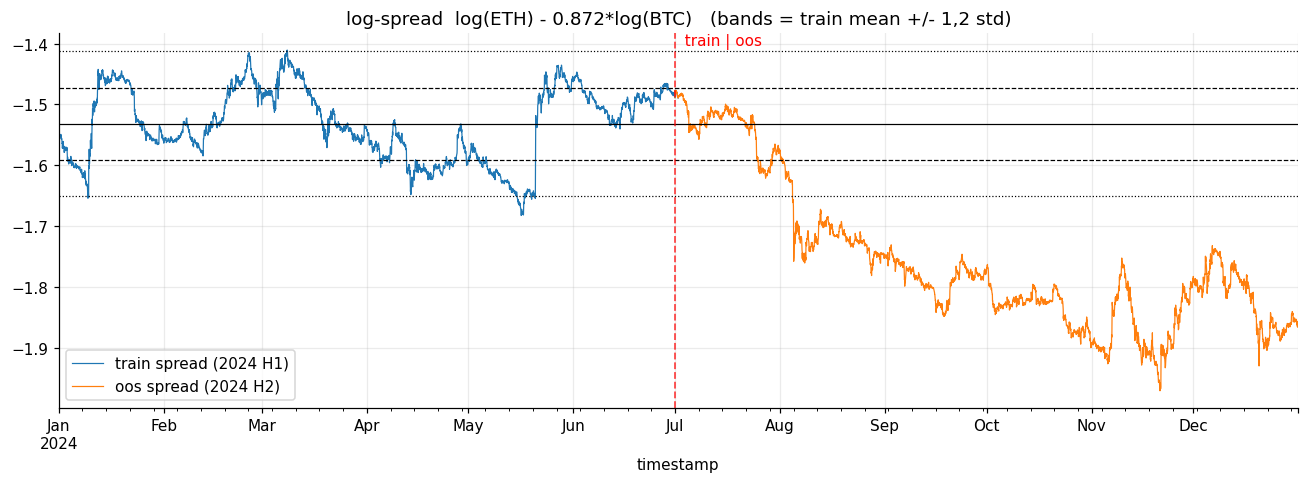

In [4]:
# --- Picture: does the OOS spread still hug the TRAIN mean/bands? -----------
fig, ax = plt.subplots(figsize=(12, 4.5))
spread_tr.plot(ax=ax,  color="C0", lw=0.8, label="train spread (2024 H1)")
spread_oos.plot(ax=ax, color="C1", lw=0.8, label="oos spread (2024 H2)")

# Bands are the TRAIN mean +/- {1,2} train-std, drawn across BOTH windows.
for k, ls in [(0, "-"), (1, "--"), (2, ":")]:
    for sgn in ({0} if k == 0 else {-1, 1}):
        ax.axhline(mu_tr + sgn * k * sd_tr, color="k", lw=0.8, ls=ls)
ax.axvline(px_oos.index[0], color="red", lw=1.2, ls="--", alpha=0.7)
ax.text(px_oos.index[0], ax.get_ylim()[1], "  train | oos", va="top", color="red")
ax.set_title(f"log-spread  log(ETH) - {beta:.3f}*log(BTC)   "
             f"(bands = train mean +/- 1,2 std)")
ax.legend(loc="lower left")
show("01_meanrev_train_oos")

### How to read the chart
The horizontal black lines are the **train** mean (solid) and ±1σ / ±2σ bands
(dashed/dotted) — *fixed from H1-2024*. Blue is the spread on train, orange is
the spread on OOS. What we want to see for a tradeable pair:

- the orange spread should keep oscillating **inside roughly the same bands**
  (mean hasn't drifted far, volatility is comparable),
- half-life should stay **short** on OOS (fast reversion persists),
- ADF p should stay **small** on OOS (still statistically mean-reverting).

If instead the orange line wanders off and never comes back, β/mean fitted on
train are stale → the "edge" would be curve-fit to H1 and we'd be trading a
broken relationship. Read the numbers above against this picture.